In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data/Replicate_011/Replicate_011_20251119: 10 NIR files
data/Replicate_012/Replicate_012_20251119: 10 NIR files
data/Replicate_021/Replicate_021_20251119: 10 NIR files
data/Replicate_022/Replicate_022_20251119: 10 NIR files

Ukupan broj XVOO_NONE NIR merenja: 40
xvoo_none_raw shape: (40, 228)


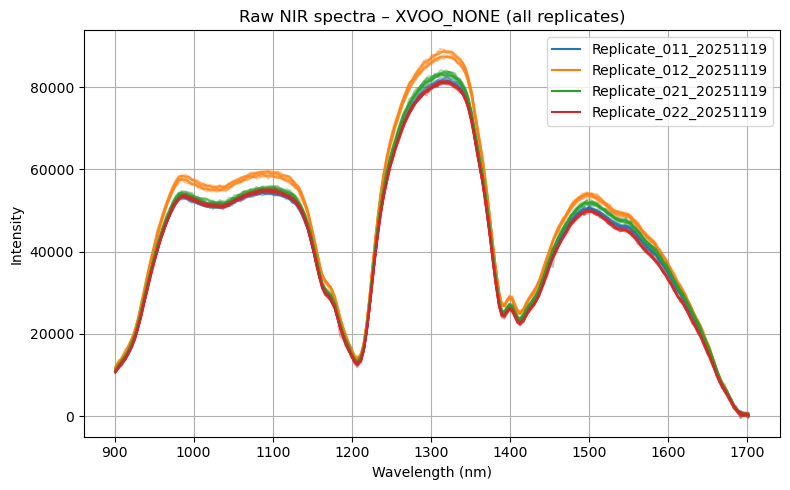

In [3]:
replicate_folders = [
    r"data/Replicate_011/Replicate_011_20251119",
    r"data/Replicate_012/Replicate_012_20251119",
    r"data/Replicate_021/Replicate_021_20251119",
    r"data/Replicate_022/Replicate_022_20251119",
    # r"data/Replicate_011/Replicate_011_20251230",
]

xvoo_none_raw = []
wavelengths = None
file_counter = 0

for base_folder in replicate_folders:
    xvoo_none_nir_path = os.path.join(base_folder, "xvoo_none", "NIR")

    if not os.path.exists(xvoo_none_nir_path):
        print(f"Warning: {xvoo_none_nir_path} does not exist, skipping...")
        continue

    files = sorted(glob.glob(os.path.join(xvoo_none_nir_path, "*.csv")))
    print(f"{base_folder}: {len(files)} NIR files")

    for fpath in files:
        df = pd.read_csv(fpath)

        if wavelengths is None:
            wavelengths = df["x"].values
        else:
            assert np.allclose(wavelengths, df["x"].values), \
                "Wavelengths do not match between replicates!"

        xvoo_none_raw.append(df["y"].values)
        file_counter += 1

xvoo_none_raw = np.array(xvoo_none_raw)

print(f"\nUkupan broj XVOO_NONE NIR merenja: {file_counter}")
print("xvoo_none_raw shape:", xvoo_none_raw.shape)

plt.figure(figsize=(8, 5))

rep_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, base_folder in enumerate(replicate_folders):
    rep_name = os.path.basename(base_folder)
    
    start_idx = sum(len(glob.glob(os.path.join(f, "xvoo_none", "NIR", "*.csv"))) 
                    for f in replicate_folders[:i])
    end_idx = start_idx + len(glob.glob(os.path.join(base_folder, "xvoo_none", "NIR", "*.csv")))
    
    spectra = xvoo_none_raw[start_idx:end_idx]
    
    for spec in spectra:
        plt.plot(wavelengths, spec, color=rep_colors[i], alpha=0.4)
    
    plt.plot([], [], color=rep_colors[i], alpha=1, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Raw NIR spectra – XVOO_NONE (all replicates)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/NIR/NIR_xvoo_none_raw.png", dpi=300, bbox_inches="tight")
plt.show()

data/Replicate_011/Replicate_011_20251119/xvoo_oo100/NIR: 10 NIR files
data/Replicate_011/Replicate_011_20251119/xvoo_oo50/NIR: 10 NIR files
data/Replicate_011/Replicate_011_20251205/xvoo_oo80/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251205/xvoo_oo10/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251205/xvoo_oo20/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251205/xvoo_oo30/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251205/xvoo_oo60/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251205/xvoo_oo70/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251205/xvoo_oo40/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_oo90/NIR: 30 NIR files
data/Replicate_012/Replicate_012_20251119/xvoo_oo100/NIR: 10 NIR files
data/Replicate_012/Replicate_012_20251119/xvoo_oo50/NIR: 10 NIR files
data/Replicate_012/Replicate_012_20251205/xvoo_oo80/NIR: 30 NIR files
data/Replicate_012/Replicate_012_20251205/xvoo_oo10/NIR: 30 NIR files
data/Replicate_012

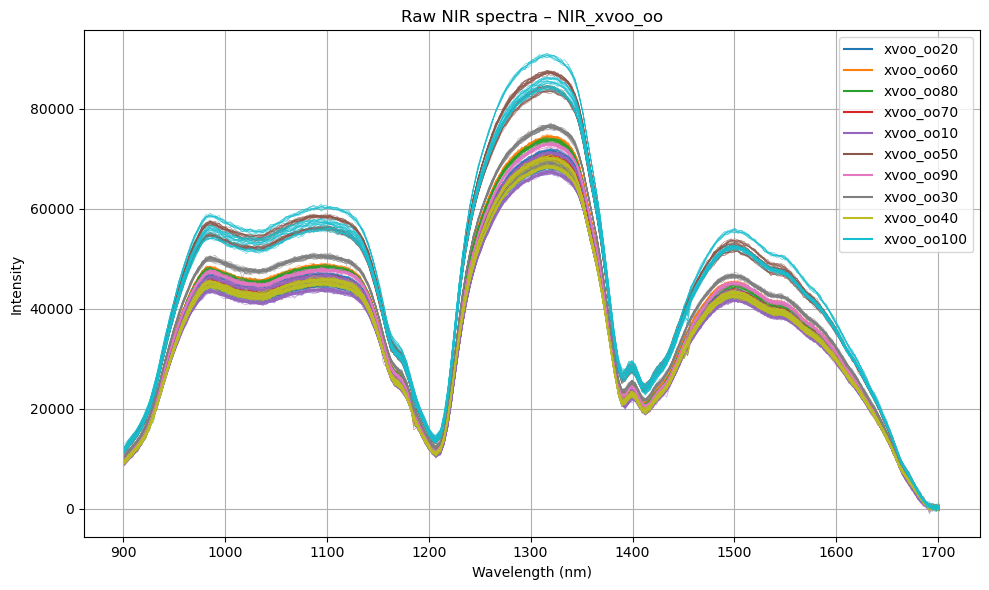

In [4]:
replicate_folders = [
    r"data/Replicate_011/Replicate_011_20251119",
    r"data/Replicate_011/Replicate_011_20251205",
    r"data/Replicate_011/Replicate_011_20251230",
    r"data/Replicate_012/Replicate_012_20251119",
    r"data/Replicate_012/Replicate_012_20251205",
    r"data/Replicate_021/Replicate_021_20251119",
    r"data/Replicate_022/Replicate_022_20251119",
]

xvoo_oo_spectra = []
wavelengths = None
file_counter = 0
sample_names = []

for base_folder in replicate_folders:
    subfolders = [f for f in os.listdir(base_folder) 
                  if os.path.isdir(os.path.join(base_folder, f)) and "xvoo_oo" in f.lower()]
    
    for subf in subfolders:
        nir_path = os.path.join(base_folder, subf, "NIR")
        if not os.path.exists(nir_path):
            print(f"Warning: {nir_path} does not exist, skipping...")
            continue
        
        files = sorted(glob.glob(os.path.join(nir_path, "*.csv")))
        print(f"{nir_path}: {len(files)} NIR files")
        
        for fpath in files:
            df = pd.read_csv(fpath)
            
            if wavelengths is None:
                wavelengths = df["x"].values
            else:
                assert np.allclose(wavelengths, df["x"].values), \
                    "Wavelengths do not match between files!"
            
            xvoo_oo_spectra.append(df["y"].values)
            file_counter += 1
            sample_names.append(subf)

xvoo_oo_spectra = np.array(xvoo_oo_spectra)
print(f"\nUkupan broj NIR merenja mešavina xvoo_oo: {file_counter}")
print("xvoo_oo_spectra shape:", xvoo_oo_spectra.shape)

plt.figure(figsize=(10, 6))

unique_samples = list(set(sample_names))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_samples)))

for i, sample in enumerate(unique_samples):
    indices = [j for j, s in enumerate(sample_names) if s == sample]
    spectra = xvoo_oo_spectra[indices]
    
    for spec in spectra:
        plt.plot(wavelengths, spec, color=colors[i], alpha=0.7, linewidth=0.4)
    
    plt.plot([], [], color=colors[i], alpha=1, label=sample)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Raw NIR spectra – NIR_xvoo_oo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/NIR/NIR_xvoo_oo.png", dpi=300, bbox_inches="tight")
plt.show()

data/Replicate_011/Replicate_011_20251119/xvoo_lso50/NIR: 10 NIR files
data/Replicate_011/Replicate_011_20251119/xvoo_lso100/NIR: 10 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_lso30/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_lso40/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_lso20/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_lso80/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_lso60/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_lso70/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_lso100/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_lso90/NIR: 30 NIR files
data/Replicate_011/Replicate_011_20251230/xvoo_lso10/NIR: 30 NIR files
data/Replicate_012/Replicate_012_20251119/xvoo_lso50/NIR: 10 NIR files
data/Replicate_012/Replicate_012_20251119/xvoo_lso100/NIR: 10 NIR files
data/Replicate_021/Replicate_021_20251119/xvoo_lso50/NIR: 10 NIR files
dat

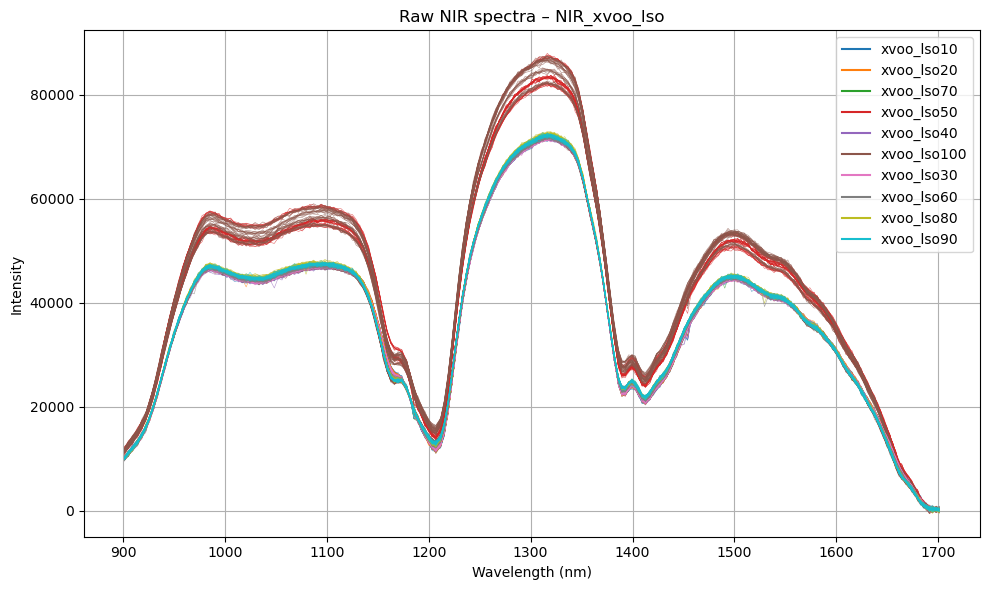

In [5]:
replicate_folders = [
    r"data/Replicate_011/Replicate_011_20251119",
    r"data/Replicate_011/Replicate_011_20251205",
    r"data/Replicate_011/Replicate_011_20251230",
    r"data/Replicate_012/Replicate_012_20251119",
    r"data/Replicate_012/Replicate_012_20251205",
    r"data/Replicate_021/Replicate_021_20251119",
    r"data/Replicate_022/Replicate_022_20251119",
]

xvoo_oo_spectra = []
wavelengths = None
file_counter = 0
sample_names = []

for base_folder in replicate_folders:
    subfolders = [f for f in os.listdir(base_folder) 
                  if os.path.isdir(os.path.join(base_folder, f)) and "xvoo_lso" in f.lower()]
    
    for subf in subfolders:
        nir_path = os.path.join(base_folder, subf, "NIR")
        if not os.path.exists(nir_path):
            print(f"Warning: {nir_path} does not exist, skipping...")
            continue
        
        files = sorted(glob.glob(os.path.join(nir_path, "*.csv")))
        print(f"{nir_path}: {len(files)} NIR files")
        
        for fpath in files:
            df = pd.read_csv(fpath)
            
            if wavelengths is None:
                wavelengths = df["x"].values
            else:
                assert np.allclose(wavelengths, df["x"].values), \
                    "Wavelengths do not match between files!"
            
            xvoo_oo_spectra.append(df["y"].values)
            file_counter += 1
            sample_names.append(subf)

xvoo_oo_spectra = np.array(xvoo_oo_spectra)
print(f"\nUkupan broj NIR merenja mešavina xvoo_oo: {file_counter}")
print("xvoo_oo_spectra shape:", xvoo_oo_spectra.shape)

plt.figure(figsize=(10, 6))

unique_samples = list(set(sample_names))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_samples)))

for i, sample in enumerate(unique_samples):
    indices = [j for j, s in enumerate(sample_names) if s == sample]
    spectra = xvoo_oo_spectra[indices]
    
    for spec in spectra:
        plt.plot(wavelengths, spec, color=colors[i], alpha=0.7, linewidth=0.4)
    
    plt.plot([], [], color=colors[i], alpha=1, label=sample)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Raw NIR spectra – NIR_xvoo_lso")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/NIR/NIR_xvoo_lso.png", dpi=300, bbox_inches="tight")
plt.show()

data/Replicate_011/Replicate_011_20251119/xvoo_sfo100/NIR: 10 NIR files
data/Replicate_011/Replicate_011_20251119/xvoo_sfo50/NIR: 10 NIR files
data/Replicate_012/Replicate_012_20251119/xvoo_sfo100/NIR: 10 NIR files
data/Replicate_012/Replicate_012_20251119/xvoo_sfo50/NIR: 10 NIR files
data/Replicate_021/Replicate_021_20251119/xvoo_sfo100/NIR: 10 NIR files
data/Replicate_021/Replicate_021_20251119/xvoo_sfo50/NIR: 10 NIR files
data/Replicate_022/Replicate_022_20251119/xvoo_sfo100/NIR: 10 NIR files
data/Replicate_022/Replicate_022_20251119/xvoo_sfo50/NIR: 10 NIR files

Ukupan broj NIR merenja mešavina xvoo_oo: 80
xvoo_oo_spectra shape: (80, 228)


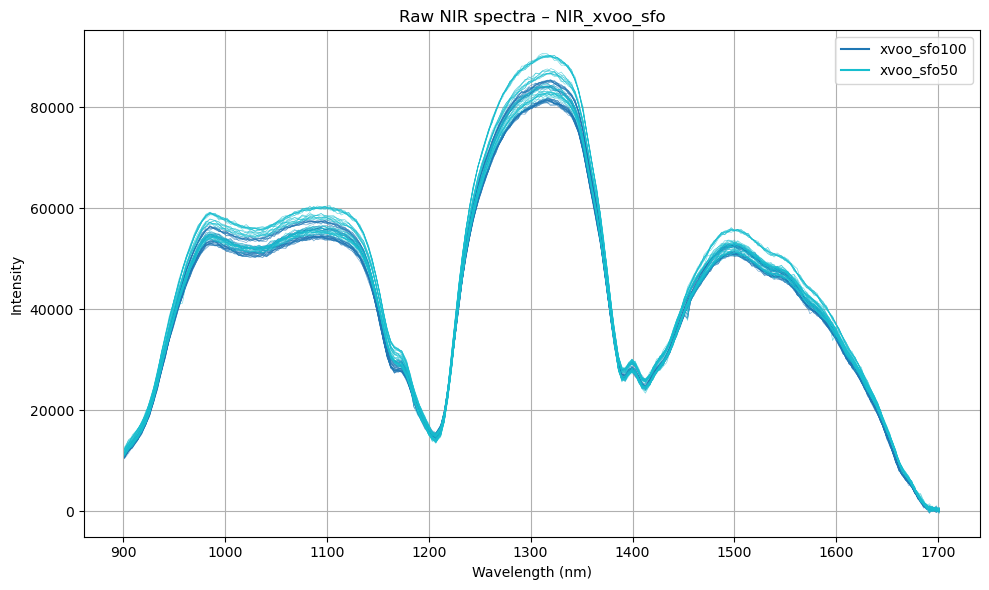

In [6]:
replicate_folders = [
    r"data/Replicate_011/Replicate_011_20251119",
    r"data/Replicate_011/Replicate_011_20251205",
    r"data/Replicate_011/Replicate_011_20251230",
    r"data/Replicate_012/Replicate_012_20251119",
    r"data/Replicate_012/Replicate_012_20251205",
    r"data/Replicate_021/Replicate_021_20251119",
    r"data/Replicate_022/Replicate_022_20251119",
]

xvoo_oo_spectra = []
wavelengths = None
file_counter = 0
sample_names = []

for base_folder in replicate_folders:
    subfolders = [f for f in os.listdir(base_folder) 
                  if os.path.isdir(os.path.join(base_folder, f)) and "xvoo_sfo" in f.lower()]
    
    for subf in subfolders:
        nir_path = os.path.join(base_folder, subf, "NIR")
        if not os.path.exists(nir_path):
            print(f"Warning: {nir_path} does not exist, skipping...")
            continue
        
        files = sorted(glob.glob(os.path.join(nir_path, "*.csv")))
        print(f"{nir_path}: {len(files)} NIR files")
        
        for fpath in files:
            df = pd.read_csv(fpath)
            
            if wavelengths is None:
                wavelengths = df["x"].values
            else:
                assert np.allclose(wavelengths, df["x"].values), \
                    "Wavelengths do not match between files!"
            
            xvoo_oo_spectra.append(df["y"].values)
            file_counter += 1
            sample_names.append(subf)

xvoo_oo_spectra = np.array(xvoo_oo_spectra)
print(f"\nUkupan broj NIR merenja mešavina xvoo_oo: {file_counter}")
print("xvoo_oo_spectra shape:", xvoo_oo_spectra.shape)

plt.figure(figsize=(10, 6))

unique_samples = list(set(sample_names))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_samples)))

for i, sample in enumerate(unique_samples):
    indices = [j for j, s in enumerate(sample_names) if s == sample]
    spectra = xvoo_oo_spectra[indices]
    
    for spec in spectra:
        plt.plot(wavelengths, spec, color=colors[i], alpha=0.7, linewidth=0.4)
    
    plt.plot([], [], color=colors[i], alpha=1, label=sample)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Raw NIR spectra – NIR_xvoo_sfo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/NIR/NIR_xvoo_sfo.png", dpi=300, bbox_inches="tight")
plt.show()